In [5]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import fetch_california_housing


In [6]:
# STEP 2: Load Dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [7]:
# Target = "MedHouseVal" (we treat it as demand proxy)

# STEP 3: Feature Engineering (Simulating Operations Data)
df['demand'] = df['MedHouseVal'] * 1000  # scale to simulate operational demand

df['region_factor'] = df['Latitude'] + df['Longitude']

In [8]:
# STEP 4: Define Features
X = df.drop(columns=['MedHouseVal', 'demand'])
y = df['demand']

In [9]:
# STEP 5: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# STEP 6: Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
# STEP 7: Evaluate Model
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print("\nModel MAE:", mae)


Model MAE: 306.8258654312015


In [12]:
# STEP 8: Workforce Optimization Logic
def calculate_workers(demand):
    return np.ceil(demand / 500)

df['predicted_demand'] = model.predict(X)
df['workers_needed'] = df['predicted_demand'].apply(calculate_workers)

In [13]:
# STEP 9: Simulated Real-Time Output
sample = df.sample(10)

print("\n--- Real-Time Workforce Allocation ---")
for _, row in sample.iterrows():
    print(
        f"Demand: {int(row['predicted_demand'])} | "
        f"Workers Needed: {int(row['workers_needed'])}"
    )


--- Real-Time Workforce Allocation ---
Demand: 1164 | Workers Needed: 3
Demand: 1050 | Workers Needed: 3
Demand: 3152 | Workers Needed: 7
Demand: 544 | Workers Needed: 2
Demand: 4559 | Workers Needed: 10
Demand: 2347 | Workers Needed: 5
Demand: 1941 | Workers Needed: 4
Demand: 2061 | Workers Needed: 5
Demand: 1093 | Workers Needed: 3
Demand: 3385 | Workers Needed: 7


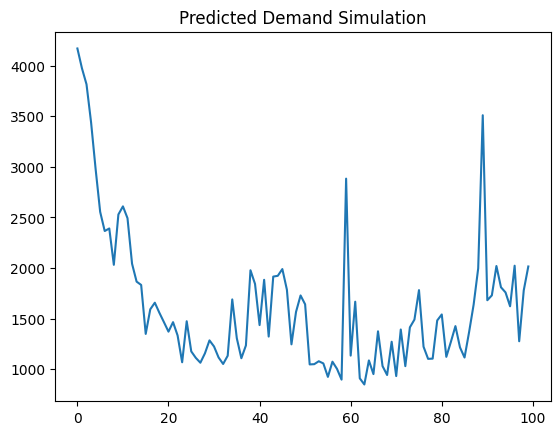

In [14]:
# STEP 10: Visualization
plt.figure()
plt.plot(df['predicted_demand'][:100])
plt.title("Predicted Demand Simulation")
plt.show()